##### KNN is supervised learning algorithm used for classification and regression tasks.
##### it is non-parametric and lazy learning algorithm.


In [1]:
import pandas as pd 
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


classification

In [ ]:
df = sns.load_dataset('iris')
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [5]:
# predicting species by size of petels
X = df.drop('species', axis=1)
y= df['species']


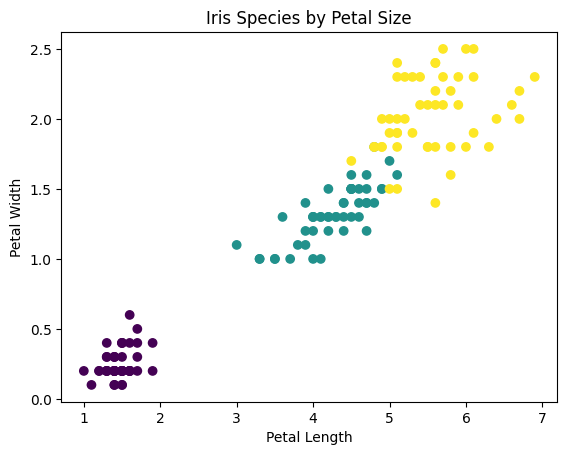

In [9]:
# plot data
plt.scatter(df['petal_length'], df['petal_width'], c=pd.Categorical(df['species']).codes)
plt.xlabel('Petal Length')
plt.ylabel('Petal Width')
plt.title('Iris Species by Petal Size')
plt.show()

In [19]:
# train test split
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier

X_test, X_train, y_test, y_train = train_test_split(X, y, test_size=0.2, random_state=42)

model = KNeighborsClassifier(n_neighbors=11)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

# evaluate model
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
print('Confusion matrix: ')
print(confusion_matrix(y_test, y_pred))
print('Classification report: ')
print(classification_report(y_test, y_pred))
print('Accuracy: ')
print(accuracy_score(y_test, y_pred))


Confusion matrix: 
[[40  0  0]
 [ 1 38  2]
 [ 0  7 32]]
Classification report: 
              precision    recall  f1-score   support

      setosa       0.98      1.00      0.99        40
  versicolor       0.84      0.93      0.88        41
   virginica       0.94      0.82      0.88        39

    accuracy                           0.92       120
   macro avg       0.92      0.92      0.92       120
weighted avg       0.92      0.92      0.92       120

Accuracy: 
0.9166666666666666


In [15]:
model.predict([[1.1, 2, 1.1, 0.1]])

c:\Users\iT LOGIX\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


array(['setosa'], dtype=object)

<Axes: >

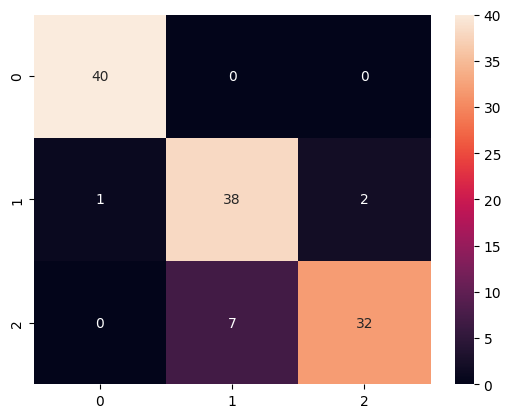

In [11]:
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d')

Regression using tips data

In [30]:
tips = sns.load_dataset("tips")

X = tips.drop("tip", axis=1)
y = tips['tip']


In [31]:
tips.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   total_bill  244 non-null    float64 
 1   tip         244 non-null    float64 
 2   sex         244 non-null    category
 3   smoker      244 non-null    category
 4   day         244 non-null    category
 5   time        244 non-null    category
 6   size        244 non-null    int64   
dtypes: category(4), float64(2), int64(1)
memory usage: 7.4 KB


In [32]:
from sklearn.preprocessing import LabelEncoder
for col in X.columns:
    if X[col].dtype == 'object' or X[col].dtype == 'category':
        le = LabelEncoder()
        X[col] = le.fit_transform(X[col])

In [34]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor

model = KNeighborsRegressor(n_neighbors=5, metric='minkowski', p=2)

X_test, X_train, y_test, y_train = train_test_split(X, y, test_size=0.2, random_state=42)   

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

# evaluate
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("Mean Absolute Error:", mean_absolute_error(y_test, y_pred))
print("Mean Squared Error:", mean_squared_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

Mean Absolute Error: 0.8347282051282051
Mean Squared Error: 1.3993435076923078
R2 Score: 0.3112475366146433


In [35]:
X_test.head()

,total_bill,sex,smoker,day,time,size
228,13.28,1,0,1,0,2
208,24.27,1,1,1,0,2
96,27.28,1,1,0,0,2
167,31.71,1,0,2,0,4
84,15.98,1,0,3,1,2


In [42]:
X

,total_bill,sex,smoker,day,time,size
0,16.99,0,0,2,0,2
1,10.34,1,0,2,0,3
2,21.01,1,0,2,0,3
3,23.68,1,0,2,0,2
4,24.59,0,0,2,0,4
...,...,...,...,...,...,...
239,29.03,1,0,1,0,3
240,27.18,0,1,1,0,2
241,22.67,1,1,1,0,2
242,17.82,1,0,1,0,2
